In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("./src")
from analysis import *

In [3]:
italy_df = pd.read_csv("./data/processed/serie_a_final_standings.csv")
england_df = pd.read_csv("./data/processed/england_top_league_standings.csv")
germany_df = pd.read_csv("./data/processed/germany_bundesliga_standings.csv")
spain_df = pd.read_csv("./data/processed/spain_la_liga_standings.csv")
france_df = pd.read_csv("./data/processed/france_ligue1_standings.csv")

print(italy_df.shape)
print(england_df.shape)
print(germany_df.shape)
print(spain_df.shape)
print(france_df.shape)

(1455, 14)
(1691, 15)
(1114, 15)
(1464, 16)
(1554, 16)


# Teams and Cities dominance in the Major European Leagues

The last round of the 2025-26 Italian Serie A league has been an upsetting day for Juventus and AC Milan, two of the most celebrated and successful teams of the Italian league. The final standing saw Inter winning the league but it was the only team of the so-called "strisciate" to finish in the first four places of the table and so earning a spot for the 2026-27 Europe Champions League. Commentators were left asking themselves, how rare it was that only one of these teams finished in the top four spots in the final standing. I was curious as well, as most Italian football fans are, we see Juventus, Inter and Milan as a kind of gang for themselves: the self-appointed bosses of Serie A, or so fans of other clubs have always felt, owner of the Serie A (and their referees: fans are happy to think that if teams are so successful is because they also are helped by referees. And luck. And deities. And we can go on with the list).

So I decided to have a look to Italian Serie A final standings in the last 80 years, from season 1946 onward, i.e. after the second world war, to see if this "felt" dominance is fact based or is another fan hallucination. But even if we will find this is not true, we can't change our mind anyway: that's the rule of every football fan.

But every time I start with a simple quest involving data, I also end up asking more question and, in this case, was "what about other countries?". I am pretty sure Italian football has been dominated by these three teams, but is the same in the rest of Europe? So I also collected the data for England, Spain, Germany and France to see if their pattern looked different or not.

Sometimes, the best Data Science projects starts with strong unfounded opinion, prejudices we carry on with us and never bother to confirm them with any data. That's the life we enjoy. In this case, I am sure Italian football has been dominated by the three strisciate, in the ways I have explained earlier, but what about other leagues? That relies mostly on my memory, which of course does not cover eighty seasons, from what I can sense, if you ask me if there are dominant teams in England, Spain, Germany and France like in Italy i would bet: 

 - **England**: not sure. I would say Manchester United, Man City (but I know their success is quite recent as they were considered the city ugly duckling), Liverpool, maybe Arsenal. I also remember the legendary Nottingham Forest winning what was the old Champions League in my first european final I ever watched on TV versus Hamburger SV. By the way, they both ended up to be, for different reasons, teams that I enjoyed support.
 - **Spain**: that is easy as, for me, there are only Barcelona and Real Madrid, with Atlético Madrid being a far third.
 - **Germany**: Bayern Munich. In my mind, Bayern owns the Bundesliga and they keep their keys close to their BMW ones. They decide when it opens, closes, if the weather is good to play and the color of each other teams shirts. Other teams sporadically show up when your team is playing agains them and you tell to yourself - "oh, Bayer allowed them to have a day out, how nice". Aside Hamburg, I also know Hamburger SV (they were Europe Champions beating Juventus in one of my best day in football), VfB Stuttgart (they played against Napoli in the UEFA Cup Final in a day that topped Juventus vs Hamburger), Borussia Dortmund (Jürgen Klopp), FC St. Pauli (the coolest team in the world), Hertha BSC and FC Union Berlin because I lived in Berlin. But they are irrelevant with respect to Bayern Munich success
 - **France**: Paris Saint-Germain FC in the recent years for sure. Before, I have memories of OM Marseille and Saint-Étienne (the club in which Michel Platini was the leader). But in terms of dominance, I pride myself of knowing nothing and curious to see what's their history.

 Now that I set the starting point, let's collect the data and see what we can understand.

## The data sources: Wikipedia

The easiest way to retrieve the data I needed, i.e. the final tables of each league, was to scrape the Wikipedia pages of each league seasons. There is a dedicated notebook describing the whole process, just a few words of the major point you need to know if you want to do by yourself.
- I went for the english version of all leagues. The link format may change over time as, for example, the English League was first called First Division (`{year}–{yy}_Football_League_First_Division`) and then change name to the current Premier League (`{year}–{yy}_Premier_League`);
- Tables inside each webpage are mostly consistent except some cases where columns where added at a later stage (e.g. `AVg` not always present in each season)
- Team names might change depending on the year (e.g. `AC Milan` vs `Milan`, `Inter Milan` vs `Internazionale`)
- 1996-97 season for Spanish La Liga has a malformed HTML table with a corrupted rowspan attribute.
- German Bundesliga starts at season 1963/64, the first single division highest tier. Before, it was handled differently, because they are German and we are not surprised. As we want to analyse the top 4 teams for each country, the easiest way was considering German Bundesliga starting from that season onward. Could I make a different choice? Yes, but it was easier this way.

Wikipedia community is fantastic and I think they deserve all the possible praises. It took some time to clean a little bit the data and understand why the scraping was, sometimes, failing but is for free. And reliable. And if you have strong criticism, start your own project and show you're better. So, for me, a shout out to Wikipedia!

Alternatives to Wikipedia that I also considered were `worldfootball.net` and `football-data.co.uk` but they were more challenging, the first, or did not cover all seasons I wanted the latter. 


## Italian Serie A. A League of Two Cities.

"*It was the best of times (for Juventus, Inter and Milan fans), it was the worst of times (the others including me)*"

It's always best practice to start from the beginning, unless you are [Sergio Leone](https://en.wikipedia.org/wiki/Once_Upon_a_Time_in_America), [Michel Gondry](https://en.wikipedia.org/wiki/Eternal_Sunshine_of_the_Spotless_Mind), [Akira Kurosawa](https://en.wikipedia.org/wiki/Rashomon) or any other great artist who can masterfully manage the art of non linear narrative. Our first question was very clear and precise: "is it an anomaly that just one team, between Juventus, Inter and Milan, finished in the first top four spots at the end of the season?". It's well known that these three clubs represent the hegemonic powers in Italian Serie A having won 62 Serie A titles in the last 80 seasons, close to the $80\%$ of the overall number of scudetto, while the remaining 18 titles where split between 9 other clubs. 

In [4]:
(compute_league_winners(italy_df)['Team']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'Team', 'count': 'Titles'})
)

,Team,Titles
0,Juventus,30
1,Milan,16
2,Inter Milan,16
3,Torino,4
4,Napoli,4
5,Fiorentina,2
6,Lazio,2
7,Roma,2
8,Bologna,1
9,Cagliari,1


That's really a tale of two cities: Torino and Milano. The first one amassed a total of 34 titles combining exactly the $80\%$ of the total, the latter trailing at 32, while other seven cities had to share 14 titles.

In [5]:
(compute_league_winners(italy_df)['City']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'City', 'count': 'Titles'})
)

,City,Titles
0,Torino,34
1,Milano,32
2,Roma,4
3,Napoli,4
4,Firenze,2
5,Bologna,1
6,Cagliari,1
7,Verona,1
8,Genova,1


Just with these share numbers, the dominance is crystal clear. But what about the top 4 spots? Let's build a table computing the results of the strisciate for each season after WWII. 

In [6]:
strisciate_df = (compute_dominant_teams(italy_df, ['Juventus', 'Inter Milan', 'Milan'])
 .rename(columns={'number_of_dominant': 'n. of strisciate', 
                  'dominant': 'teams'})
)

strisciate_df[:5]

,season,n. of strisciate,teams,positions,points
0,1946/47,2,"[Juventus, Milan]","[2, 10, 4]","[53, 36, 50]"
1,1947/48,2,"[Juventus, Milan]","[3, 12, 2]","[49, 37, 49]"
2,1948/49,3,"[Juventus, Inter Milan, Milan]","[4, 2, 3]","[44, 55, 50]"
3,1949/50,3,"[Juventus, Inter Milan, Milan]","[1, 3, 2]","[62, 49, 57]"
4,1950/51,3,"[Juventus, Inter Milan, Milan]","[3, 2, 1]","[54, 59, 60]"


The table indicates that for season 1946/47, two of the striciate, Juventus and Milan, finished the season in the top 4, respectively second and fourth places while Inter was in tenth place. Juventus scored 53 points, Milan 50 and Inter Milan 36 (the order in which to read `positions` and `points` is `Juventus`, `Inter Milan` and `Milan` respectively). In season 1949/50, they topped the first three places with Juventus first, Inter Milan third, and Milan second place. 

Using the table we can compute a summary that will tell us in how many seasons all three clubs occupied one of the first four spots, which seasons two of them and, finally like this season, just one team finished in the first 4. 

In [7]:
table_top_4_ita = (strisciate_df
 .value_counts("n. of strisciate")
 .sort_index(ascending=False)
 .reset_index()
 .rename(columns={"count": "total"})
 .assign(pct=lambda x: (x["total"] / x["total"].sum()).round(3))
)

table_top_4_ita

,n. of strisciate,total,pct
0,3,28,0.350
1,2,37,0.462
2,1,15,0.188


So, in just 15 seasons did only one *strisciata* finish in the top four, leaving the remaining two in a lower position. Less than $20\%$ of the total, less than 1 in 5 seasons. Can we agree it is a sign of dominance? By the way, in eighty seasons, Juventus missed just one Serie A season, Milan two. Yes, I like it when I remind it that it was for a fraud case (in the case of Juventus and one occurence for Milan).

The following plot shows the temporal trend of the top 4 spot.

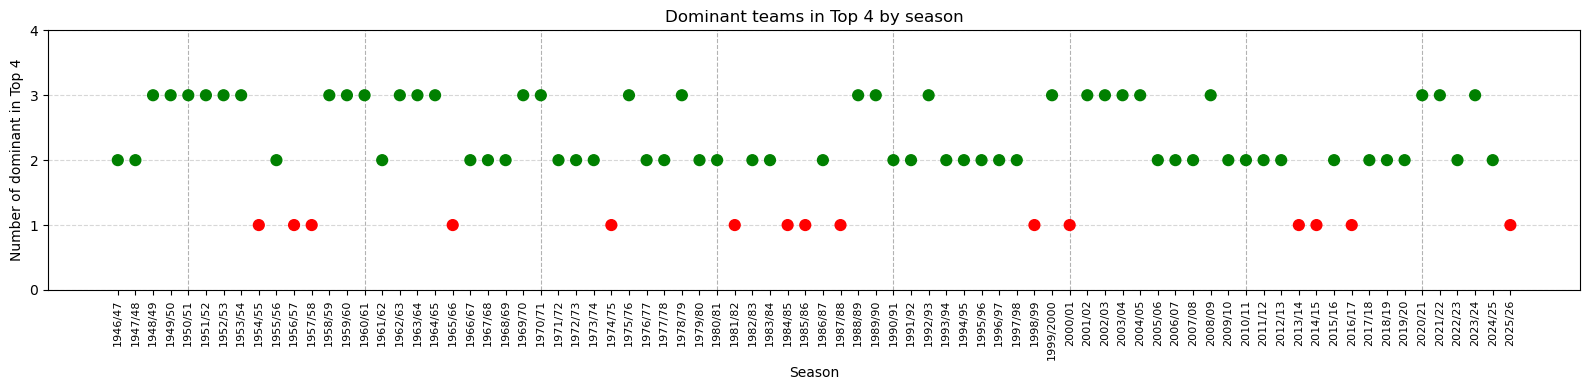

In [8]:
plot_dominant_teams(compute_dominant_teams(italy_df, ['Juventus', 'Inter Milan', 'Milan']))

The plot shows the few misses concentrating in the '50, the '80 and the second decade of 2000. It is interesting to note a strong dominance in the first decade of the 2000, followed by what it looks like a "decadence" with just in season 2020-21 all three teams regained the first 4 spots after more than a decade.  

So far we definitely find data supporting the dominance of the three clubs belonging the the strisciate, but what if we consider other teams that may be regarded as dominant? Not in terms of winning titles, of course, as we already saw how other clubs had to share very little success compared to the strisciate.

A way to respond to the latter question, is to consider other teams and see if by changing the composition of three dominant teams, we see a higher or similar rate of top 4 spots occupancy with a different combinations. 

In [9]:
list_of_teams = ['Juventus', 'Inter Milan', 'Milan', 'Roma', 'Fiorentina', 'Lazio', 'Napoli', 'Torino']

(compute_dominant_combinations(italy_df, list_of_teams)
 .sort_values('at_least_2_of_3_pct', ascending = False)
 .head(7)
 .reset_index(drop=True)
)[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

,combination,0_of_3,1_of_3,2_of_3,3_of_3,at_least_2_of_3_pct
0,"(Juventus, Inter Milan, Milan)",0,15,37,28,0.812
1,"(Juventus, Milan, Roma)",2,19,57,2,0.738
2,"(Juventus, Milan, Napoli)",1,22,49,8,0.713
3,"(Juventus, Inter Milan, Napoli)",3,20,44,13,0.713
4,"(Juventus, Inter Milan, Fiorentina)",2,22,45,11,0.700
5,"(Juventus, Inter Milan, Lazio)",2,23,47,8,0.688
6,"(Juventus, Inter Milan, Roma)",2,23,46,9,0.688


Let's first notice that the parameter I chose to compare the dominance is the percentage of at least 2 teams out of 3 reached the top 4 spots. Changing the definition of the evaluation parameter, will influence the ordering. 

If we consider swapping Inter Milan with Roma, the closest contender with respect at least two of them reached the four top spot, we see a drop of more $10\%$ of occurrences. It looks like there is no real competitor. But let's see what will happen in the other leagues and see if we can spot different trends.

## English Premier League, previously known as First Division

As I admitted in the introduction, I don't have a clear picture on my mind in terms of dominant teams in the England league. To find good candidates for the dominant team, let's first see which teams participated in most, if not all, of the top league and the list of title winners with count of their titles.

In [10]:
england_df['Team'].value_counts().reset_index().rename(columns = {'count': 'n. of appearances'})[:10]

,Team,n. of appearances
0,Arsenal,80
1,Manchester United,79
2,Everton,77
3,Tottenham Hotspur,75
4,Liverpool,72
5,Chelsea,71
6,Aston Villa,67
7,Manchester City,66
8,Newcastle United,62
9,West Ham United,59


Arsenal is the only team to play in the top English league from 1946 onward. After a [troubled 1973-74 season, Manchester United was relegated in second division](https://en.wikipedia.org/wiki/1973%E2%80%9374_Manchester_United_F.C._season) so 1973-75 it's their only missing in the top table. Other teams I considered "dominant", like Liverpool, missed quite a number of top tier seasons.

In terms of won titles we have the following table:

In [11]:
(compute_league_winners(england_df)['Team']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'Team', 'count': 'Titles'})
)

,Team,Titles
0,Manchester United,18
1,Liverpool,16
2,Arsenal,9
3,Manchester City,9
4,Chelsea,6
5,Everton,4
6,Wolverhampton Wanderers,3
7,Leeds United,3
8,Portsmouth,2
9,Tottenham Hotspur,2


Which is strikingly different from Italy. 17 teams won at least one title, compared to 12 in Serie A, none of them were able to reach 20 total titles. Manchester United and Liverpool should be considered, at least at a first stage, as the strongest candidate for the hegemon clubs in England, but what about the third spot? Arsenal and Manchester City look the natural candidates, but, as we saw earlier, Arsenal is the only team not to have skipped a top tier league, while Manchester City spent 14 in the second division. So, at first, we will consider Manchester United, Liverpool and Arsenal as the corresponding *strisciate* for England. Not sure they will feel proud of the comparison.

One last thing to compare with Italian case: which are the most successful cities?

In [12]:
(compute_league_winners(england_df)['City']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'City', 'count': 'Titles'})
)

,City,Titles
0,Manchester,27
1,Liverpool,20
2,London,17
3,Wolverhampton,3
4,Leeds,3
5,Portsmouth,2
6,Derby,2
7,Burnley,1
8,Ipswich,1
9,Nottingham,1


Again, quite a difference: if in Italy we had nine different cities winning the scudetto, in England the number of different cities is larger: 13. But like in Italy, the capital city is not the most successful one: London, with its nine million people living there, was able to top the league 17 times, sharing the number of titles with three teams: Arsenal, Chelsea and Tottenham. We also have to notice that in 80 seasons, 12 different teams were from London.

In [13]:
england_df[england_df["City"] == "London"]["Team"].unique()

<StringArray>
[            'Arsenal',             'Chelsea',   'Charlton Athletic',
           'Brentford',              'Fulham',   'Tottenham Hotspur',
     'West Ham United',       'Leyton Orient', 'Queens Park Rangers',
      'Crystal Palace',           'Wimbledon',            'Millwall']
Length: 12, dtype: str

Going back to dominance, let's define Manchester United, Liverpool and Arsenal as the dominant powers and see what we can infer. 

In [14]:
english_dominant_teams = ['Manchester United', 'Liverpool', 'Arsenal']

eng_dominant_df = (compute_dominant_teams(england_df, english_dominant_teams)
 .rename(columns={'number_of_dominant': 'n. of dominant', 
                  'dominant': 'teams'})
)

eng_dominant_df[:5]

,season,n. of dominant,teams,positions,points
0,1946/47,2,"[Manchester United, Liverpool]","[2, 1, 13]","[56, 57, 41]"
1,1947/48,2,"[Manchester United, Arsenal]","[2, 11, 1]","[52, 42, 59]"
2,1948/49,1,[Manchester United],"[2, 12, 5]","[53, 40, 49]"
3,1949/50,1,[Manchester United],"[4, 8, 6]","[50, 48, 49]"
4,1950/51,1,[Manchester United],"[2, 9, 5]","[56, 43, 47]"


I ordered the position and points as `Manchester United`, `Liverpool` and `Arsenal`, this mean that in 1946-47 season, Manchester finished second, Liverpool won the title and Arsenal finished 13th (but they were the winners the next season).

In [15]:
table_top_4_eng = (eng_dominant_df
 .value_counts("n. of dominant")
 .sort_index(ascending=False)
 .reset_index()
 .rename(columns={"count": "total"})
 .assign(pct=lambda x: (x["total"] / x["total"].sum()).round(3))
)
table_top_4_eng


,n. of dominant,total,pct
0,3,11,0.138
1,2,40,0.500
2,1,22,0.275
3,0,7,0.088


That is definitely a different picture with respect to Italian strisciate. In England, less than $70\%$ of the cases saw at least two of Manchester United, Liverpool and Arsenal in the top 4, compared to more than $80\%$ of the Italian case. Also worth noticing, the 7 seasons without any of them in the top spots. We are still waiting for this kind of open competition to come to Italian football.

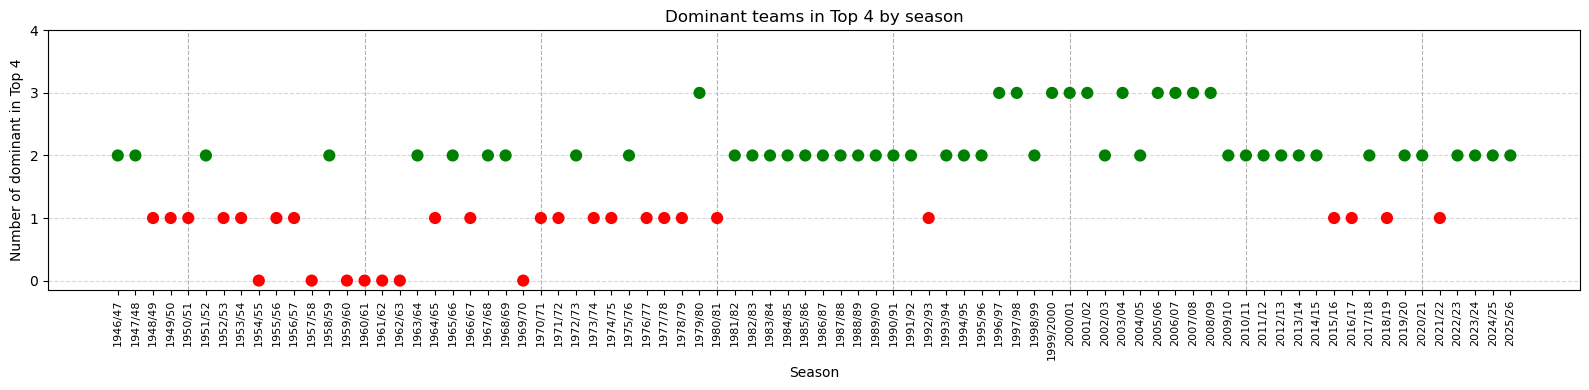

In [16]:
plot_dominant_teams(compute_dominant_teams(england_df, ['Manchester United', 'Liverpool', 'Arsenal']))

And here is where the plot shows a significant insight. The reason why we have in mind the three teams as dominant reflects their performances starting from the 1980s onward. If in the season preceding 1980, before 1980, two of the three were rarely present in the top four simultaneously; after 1980 they hardly missed a season (although we see some missing season across 2015-16 and 2021-22)

What about we change the dominant clubs definition? Let's add more successful teams and see what happens.

In [17]:
list_of_teams = ['Manchester United', 'Liverpool', 'Arsenal',
                 'Everton', 'Tottenham Hotspur', 'Chelsea', 
                 'Aston Villa', 'Manchester City']

english_dominant_combinations =(compute_dominant_combinations(england_df, list_of_teams)
 .sort_values('at_least_2_of_3_pct', ascending = False)
 #.head(10)
 .reset_index(drop=True)
)#[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

english_dominant_combinations.head(10)[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

,combination,0_of_3,1_of_3,2_of_3,3_of_3,at_least_2_of_3_pct
0,"(Manchester United, Liverpool, Arsenal)",7,22,40,11,0.637
1,"(Manchester United, Liverpool, Manchester City)",10,27,39,4,0.537
2,"(Manchester United, Liverpool, Chelsea)",9,31,32,8,0.500
3,"(Manchester United, Liverpool, Tottenham Hotspur)",4,38,33,5,0.475
4,"(Manchester United, Arsenal, Tottenham Hotspur)",8,34,35,3,0.475
5,"(Liverpool, Arsenal, Manchester City)",15,28,34,3,0.463
6,"(Manchester United, Arsenal, Manchester City)",10,35,29,6,0.438
7,"(Manchester United, Liverpool, Everton)",8,38,30,4,0.425
8,"(Liverpool, Arsenal, Tottenham Hotspur)",8,39,31,2,0.412
9,"(Manchester United, Arsenal, Everton)",10,37,32,1,0.412


In [18]:
english_dominant_combinations[english_dominant_combinations['0_of_3'] == english_dominant_combinations['0_of_3'].min()]

,combination,0_of_3,0_of_3_pct,1_of_3,1_of_3_pct,2_of_3,2_of_3_pct,3_of_3,3_of_3_pct,at_least_2_of_3,at_least_2_of_3_pct
3,"(Manchester United, Liverpool, Tottenham Hotspur)",4,0.05,38,0.475,33,0.412,5,0.062,38,0.475


From the above tables, we notice that if we switch Arsenal with Manchester City, the percentage of at least 2 teams out of three in the top for drops about the $10\%$. The original triplet numbers looks more homogeneous in terms of consistency, having the highest rate of 3/3 and a low combination of 0/3 and 1/3.

Just out of curiosity, I will produce two plots with different combinations just to see if we see some interesting pattern:

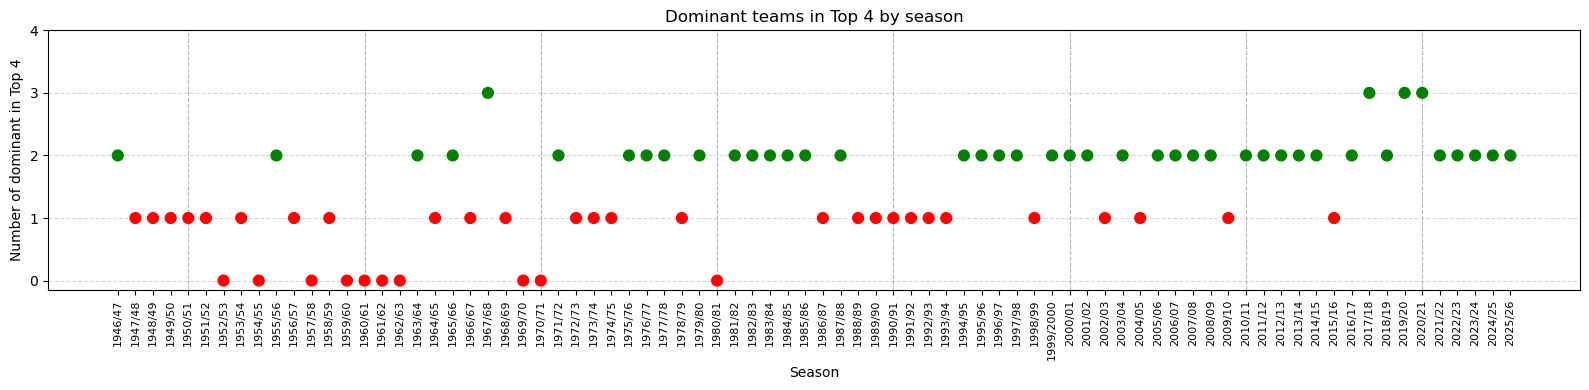

In [19]:
plot_dominant_teams(compute_dominant_teams(england_df, ['Manchester United', 'Liverpool', 'Manchester City']))

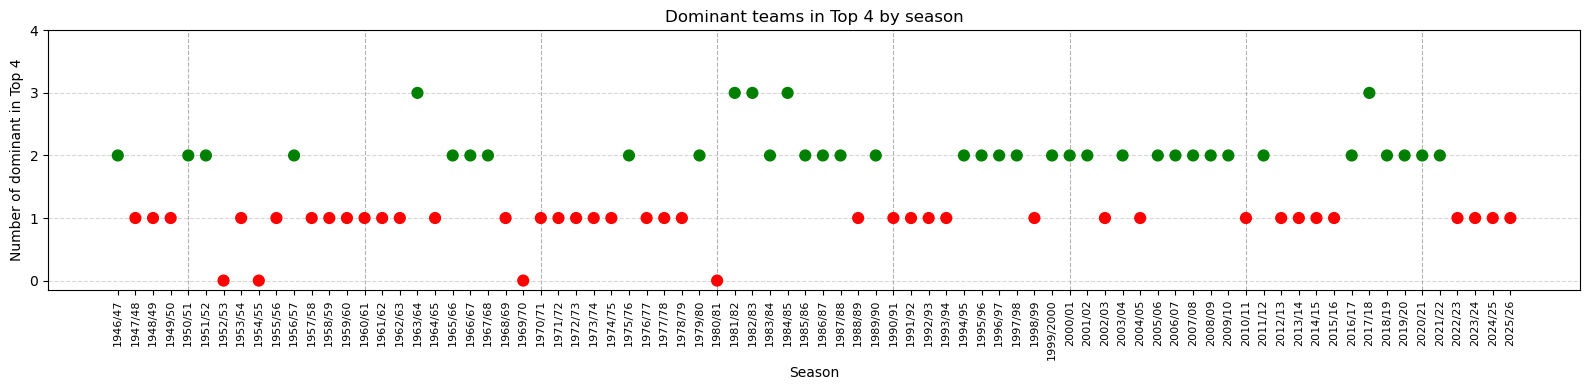

In [20]:
plot_dominant_teams(compute_dominant_teams(england_df, ['Manchester United', 'Liverpool', 'Tottenham Hotspur']))

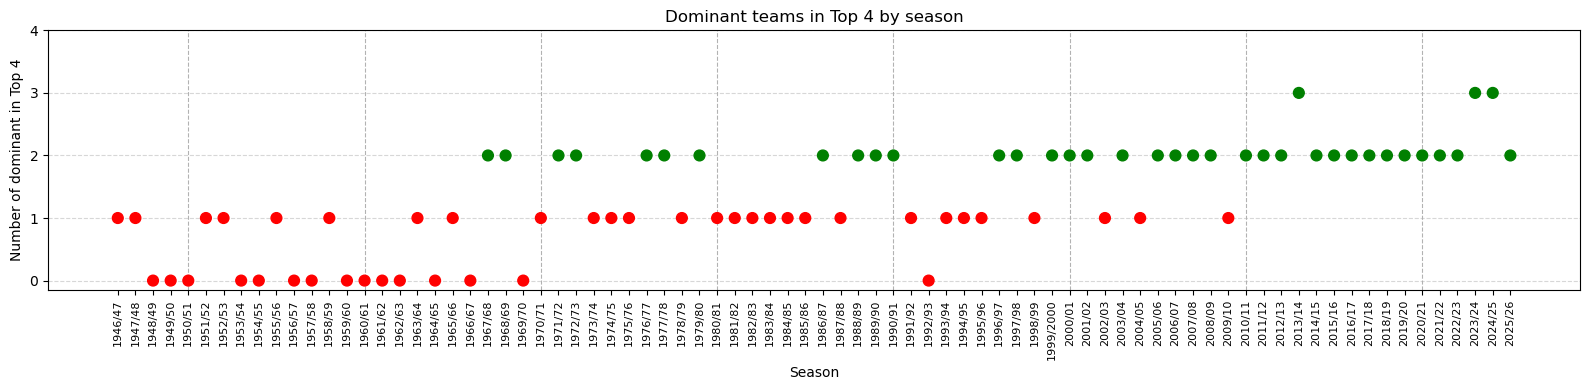

In [21]:
plot_dominant_teams(compute_dominant_teams(england_df, ['Arsenal', 'Liverpool', 'Manchester City']))

Just a short note about how Manchester City only recently surged as a Premier League top team, replacing Manchester United as the most successful city club (I am not planning any trip in the near future to Manchester anyway).

## Spanish La Liga, again a Tale of Two Cities

Ok, as for the Spanish La Liga I am just curious to see how strong is the dominance of the two main teams, Barcelona and Real Madrid. I am not expecting any surprise.

Let's first have a look to the list of title winners.

In [22]:
(compute_league_winners(spain_df)['Team']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'Team', 'count': 'Titles'})
)

,Team,Titles
0,Real Madrid,34
1,Barcelona,27
2,Atlético Madrid,9
3,Valencia,4
4,Athletic Bilbao,3
5,Real Sociedad,2
6,Deportivo La Coruña,1


Only 7 clubs managed to win La Liga from 1946-47 season, with 70 out of 80 titles ($87.5\%$) shared between Real Madrid, Barcelona and Atletico Madrid. That's what the definiton of dominance looks like. 

In [23]:
spanish_dominant_teams = ['Real Madrid', 'Barcelona', 'Atlético Madrid']

esp_dominant_df = (compute_dominant_teams(spain_df, spanish_dominant_teams)
 .rename(columns={'number_of_dominant': 'n. of dominant', 
                  'dominant': 'teams'})
)

table_top_4_esp = (esp_dominant_df
 .value_counts("n. of dominant")
 .sort_index(ascending=False)
 .reset_index()
 .rename(columns={"count": "total"})
 .assign(pct=lambda x: (x["total"] / x["total"].sum()).round(3))
)

table_top_4_esp

,n. of dominant,total,pct
0,3,33,0.412
1,2,45,0.562
2,1,2,0.025


No contest: the three teams top the first four spots in more than $90\%$ of the cases. This will be a very boring plot.

Just for the record, season 1999/2000 was an epic season, with Deportivo La Coruña winning their only title with 5 points clear to Barcelona, Real Madrid finishing fifth and Atletico relegated in second division. Season 2002/03 Real Madrid went on winning La Liga but Barcelona fell in the 6th position while Atletico arrived 12th. And that's it. 

In [24]:
spain_df['Team'].value_counts().reset_index().rename(columns = {'count': 'n. of appearances'})[:10]

,Team,n. of appearances
0,Athletic Bilbao,80
1,Barcelona,80
2,Real Madrid,80
3,Valencia,79
4,Atlético Madrid,78
5,Espanyol,74
6,Sevilla,73
7,Real Sociedad,70
8,Zaragoza,55
9,Celta Vigo,54


That's the only surprise from La Liga: I didn't know Athletic Bilbao didn't relegate since 1946, while Atletico Madrid spent 2 seasons in the lower table. The kind of information you can use to live up a party.

## Germany, *In der Bundesliga gibt’s nur ein Team / Eins, zwei, g’suffa!*

If for other leagues we picked up three teams (Spain has been a little of a stretch, we could pick up two teams), I am expecting to see just one club: Bayern Munich!

Just to create unnecessary suspance, let's first see the club participation and remind you that for Germany we have less seasons to consider.

In [25]:
germany_df['Team'].value_counts().reset_index().rename(columns = {'count': 'n. of appearances'})[:10]

,Team,n. of appearances
0,Werder Bremen,60
1,Bayern Munich,60
2,Borussia Dortmund,58
3,VfB Stuttgart,58
4,Borussia Mönchengladbach,57
5,Eintracht Frankfurt,56
6,Hamburger SV,55
7,Schalke 04,54
8,1. FC Köln,52
9,Bayer Leverkusen,46


Werder Bremen where, aside Bayern Munich, the only club not to go down from the top in the last 60 seasons (btw, I know that Hamburger SV were the latest club to ever been relegated about five years ago).

Let's count the titles, now.

In [26]:
(compute_league_winners(germany_df)['Team']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'Team', 'count': 'Titles'})
)


,Team,Titles
0,Bayern Munich,33
1,Borussia Mönchengladbach,5
2,Borussia Dortmund,5
3,Werder Bremen,4
4,Hamburger SV,3
5,VfB Stuttgart,3
6,1. FC Köln,2
7,1. FC Kaiserslautern,2
8,1860 Munich,1
9,Eintracht Braunschweig,1


The split is clear: there is Bayern Munich and then the rest of the Bundesliga. Over the $50\%$ of the titles won. Once we include Bayern in the top three teams, results are automatically shifted upwards and could be difficult to understand, aside that club, who to consider dominant in German Bundesliga.

By the way, if we plot Bayern alone we will notice that only 9 times the club did not get into the top 4 spots. And they constantly succeed in doing it from 1994/95 season.

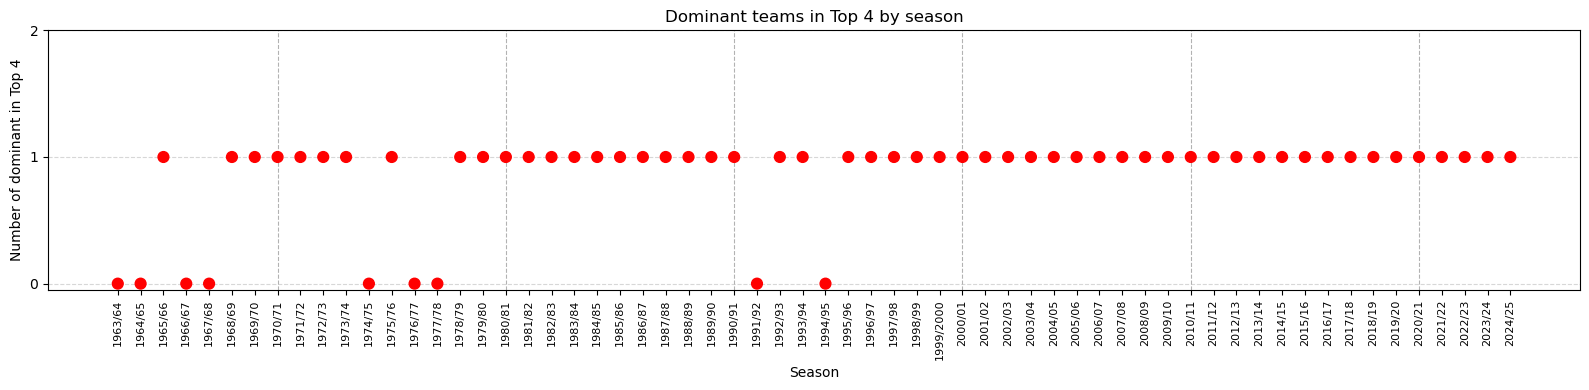

In [27]:
plot_dominant_teams(compute_dominant_teams(germany_df, ['Bayern Munich']))

In [28]:
list_of_teams = ['Bayern Munich', 'Borussia Mönchengladbach', 'Borussia Dortmund', 
                 'Werder Bremen', 'Hamburger SV', 'VfB Stuttgart']

german_dominant_combinations =(compute_dominant_combinations(germany_df, list_of_teams)
 .sort_values('at_least_2_of_3_pct', ascending = False)
 #.head(10)
 .reset_index(drop=True)
)#[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

german_dominant_combinations.head(10)[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

,combination,0_of_3,1_of_3,2_of_3,3_of_3,at_least_2_of_3_pct
0,"(Bayern Munich, Borussia Dortmund, Werder Bremen)",3,21,36,2,0.613
1,"(Bayern Munich, Borussia Dortmund, VfB Stuttgart)",3,23,34,2,0.581
2,"(Bayern Munich, Borussia Dortmund, Hamburger SV)",3,24,33,2,0.565
3,"(Bayern Munich, Borussia Mönchengladbach, Boru...",0,28,29,5,0.548
4,"(Bayern Munich, Borussia Mönchengladbach, VfB ...",4,30,27,1,0.452
5,"(Bayern Munich, Borussia Mönchengladbach, Werd...",3,31,26,2,0.452
6,"(Bayern Munich, Borussia Mönchengladbach, Hamb...",5,31,23,3,0.419
7,"(Bayern Munich, Werder Bremen, Hamburger SV)",5,34,19,4,0.371
8,"(Bayern Munich, Werder Bremen, VfB Stuttgart)",4,35,19,4,0.371
9,"(Bayern Munich, Hamburger SV, VfB Stuttgart)",6,36,14,6,0.323


As expected, there is very little variation if we swap clubs a part for Bayern Munich, with possible the triplet `Bayern Munich`,  `Borussia Dortmund`,`Werder Bremen` the one with better performances.

What is worth noticing is that, apart from Bayern Munich, it's not possible to define three teams dominating the German league, as there is a lot of variability in the remaining Bayern's competitors, as it looks like they change over years. It's striking to see the difference with Italy and Spain, where the three top clubs where $80\%$ successful in occupaying at least 2 spots in the first 4 places while in Germany they just account a little bit more than $60\%$. If England genuinely showed great variety during the last 80 years with no dominant club, in Germany there is one dominant team and then the other clubs change in being the challengers.

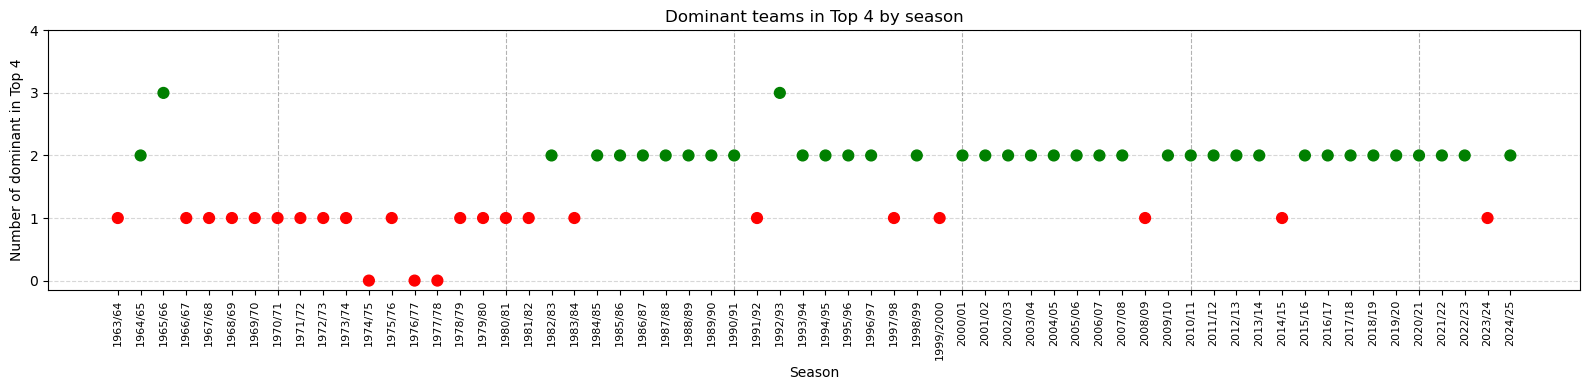

In [29]:
plot_dominant_teams(compute_dominant_teams(germany_df, ['Bayern Munich', 'Borussia Dortmund', 'Werder Bremen']))

Pushed probably by Borussia Dortmund, who lately rised as one of Bayern long standing rivals, the triplet `Bayern Munich`, `Borussia Dortmund`, `Werder Bremen` showed good performances starting from year 2000.

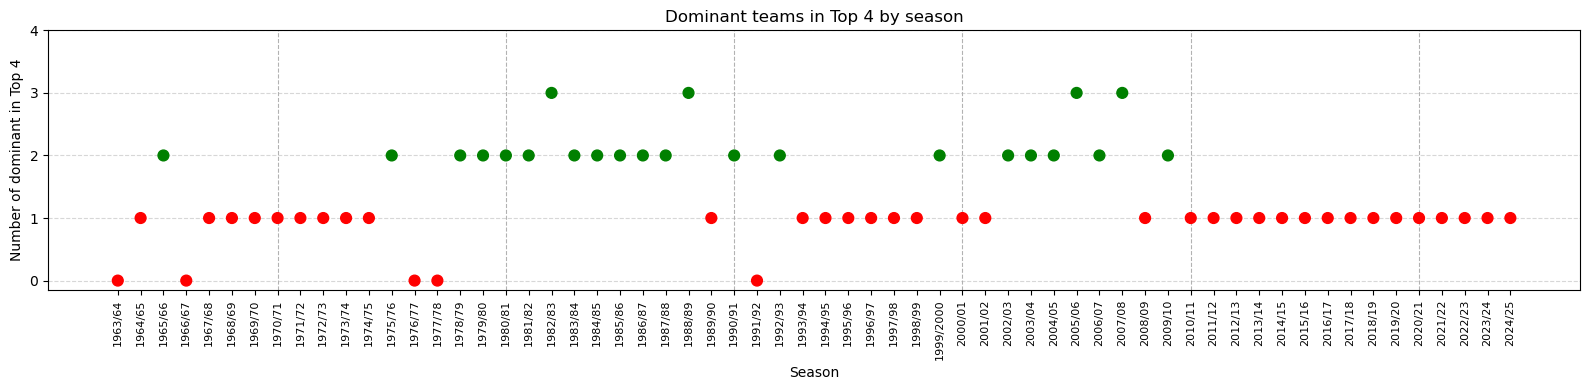

In [30]:
plot_dominant_teams(compute_dominant_teams(germany_df, ['Bayern Munich', 'Hamburger SV', 'Werder Bremen']))

Other combinations, like Bayern Munich, Hamburger SV and Werder Bremen look definitely more scattered and unbalanced.

## France, *Je ne sais pas… Je ne sais vraiment pas…*

The last league we look at is the French one, for which I don't have the slightest idea who to consider the dominant clubs, so I will let the data decide.

We start considering the participation for each team.

In [31]:
france_df['Team'].value_counts().reset_index().rename(columns = {'count': 'n. of appearances'})[:10]


,Team,n. of appearances
0,Marseille,68
1,Saint-Étienne,68
2,Bordeaux,68
3,Lyon,67
4,Monaco,67
5,Lille,65
6,Nice,65
7,Rennes,63
8,Lens,61
9,Strasbourg,59


That's something totally new for what we have seen so far: no team succeeded in participating to all Ligue 1 seasons with Marseille, Saint-Étienne and Bordeaux the ones with more competitions. Paris SG is not even in the top 10, which might be surprising for those ignoring that PSG became successful only very recently.

We now count the titles won by each team.

In [32]:
(compute_league_winners(france_df)['Team']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'Team', 'count': 'Titles'})
)

,Team,Titles
0,Paris Saint-Germain,14
1,Saint-Étienne,10
2,Marseille,9
3,Monaco,8
4,Nantes,8
5,Lyon,7
6,Reims,6
7,Bordeaux,6
8,Nice,4
9,Lille,3


France looks definitely the least dominated League of the bunch. 15 different teams winning at least one title, only England with more clubs, and no clear cluster of dominant teams.

In [33]:
france_winners = compute_league_winners(france_df)
psg = france_winners[france_winners['Team'] == 'Paris Saint-Germain']
psg['season'].unique()

<StringArray>
['1985/86', '1993/94', '2012/13', '2013/14', '2014/15', '2015/16', '2017/18',
 '2018/19', '2019/20', '2021/22', '2022/23', '2023/24', '2024/25', '2025/26']
Length: 14, dtype: str

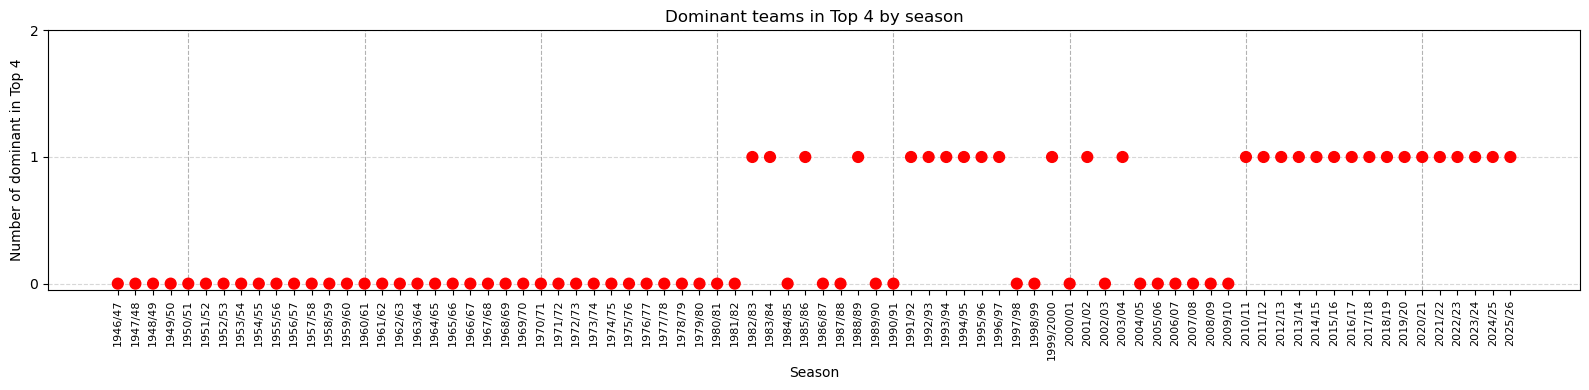

In [34]:
plot_dominant_teams(compute_dominant_teams(france_df, ['Paris Saint-Germain']))

The first PSG title goes back to 1985/86 season and, before 1982/83 season, they were not able to reach the first 4 spots at all. But 12 out of 14 titles where won in the latest 15 years. As PSG is now considered the dominant team, we can't say it's true during the last 80 years.

In [35]:
list_of_teams = ['Paris Saint-Germain','Saint-Étienne', 
                 'Marseille','Monaco','Nantes',
                 'Lyon', 'Reims', 'Bordeaux']

french_dominant_combinations =(compute_dominant_combinations(france_df, list_of_teams)
 .sort_values('at_least_2_of_3_pct', ascending = False)
 #.head(10)
 .reset_index(drop=True)
)#[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

french_dominant_combinations.head(10)[['combination', '0_of_3' , '1_of_3', '2_of_3', '3_of_3', 'at_least_2_of_3_pct']]

,combination,0_of_3,1_of_3,2_of_3,3_of_3,at_least_2_of_3_pct
0,"(Paris Saint-Germain, Marseille, Lyon)",27,24,25,4,0.362
1,"(Paris Saint-Germain, Marseille, Monaco)",19,33,21,7,0.350
2,"(Paris Saint-Germain, Monaco, Lyon)",24,28,21,7,0.350
3,"(Paris Saint-Germain, Monaco, Bordeaux)",19,33,24,4,0.350
4,"(Marseille, Monaco, Lyon)",18,35,23,4,0.338
5,"(Saint-Étienne, Marseille, Monaco)",20,33,27,0,0.338
6,"(Paris Saint-Germain, Lyon, Bordeaux)",24,30,25,1,0.325
7,"(Paris Saint-Germain, Monaco, Nantes)",23,32,24,1,0.312
8,"(Paris Saint-Germain, Saint-Étienne, Monaco)",21,34,24,1,0.312
9,"(Marseille, Monaco, Bordeaux)",14,41,21,4,0.312


The table clearly indicate how it's difficult to find three hegemon clubs in France football. 

Let's plot, for example, the triplets consisting of `Paris Saint-Germain`, `Marseille`, and `Lyon` and compare to `Saint-Étienne`, `Marseille`, and `Monaco`.

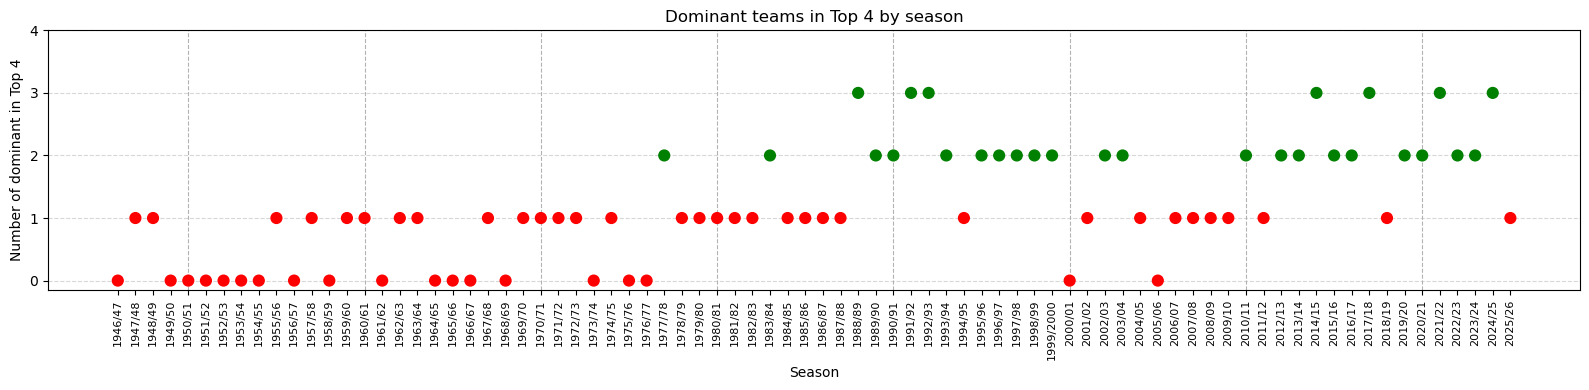

In [36]:
plot_dominant_teams(compute_dominant_teams(france_df, ['Paris Saint-Germain', 'Marseille', 'Monaco']))

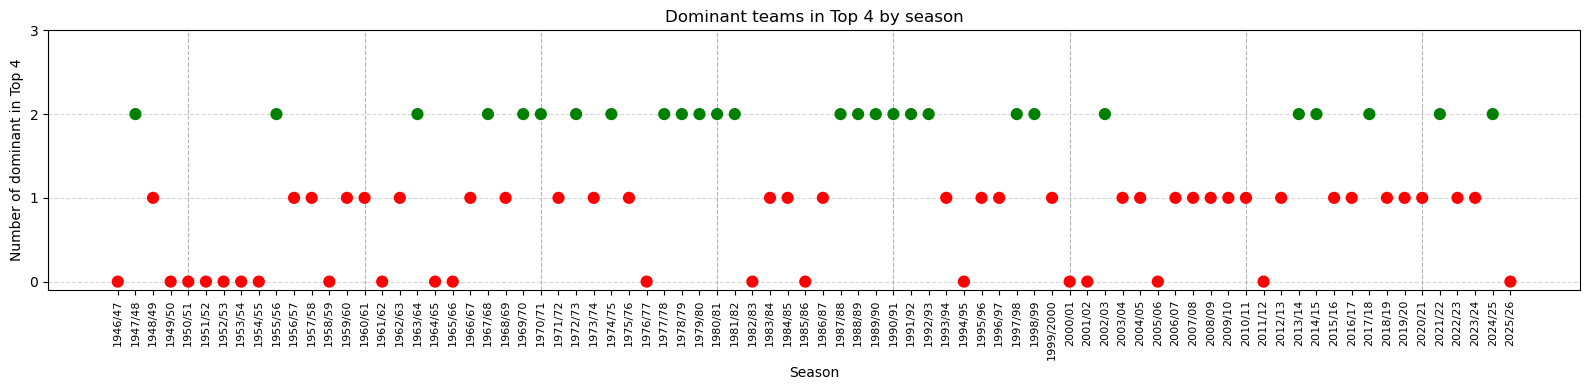

In [37]:
plot_dominant_teams(compute_dominant_teams(france_df, ['Marseille', 'Saint-Étienne', 'Monaco']))

The two plots mainly differ in their distribution of the 2/3 and 3/3 being more concentrated in the latest years (`Paris Saing-Germain`, `Marseille`, `Lyon`) or with no peak but more evenly distributed (`Saint-Étienne`, `Marseille`, and `Monaco`).

But, as suspected, France football doesn't seem to have traditionally, long standing powerhouses constantly dominating the football landscape. Except in the latest years.  

## Conclusion

We started with a very simple and straightforward question, triggered by a single Sunday of football, and, as usual as is in my habit, I was able to turn it into a wildly wider analysis. The question was: is it unusual that only one of the *strisciate* finished in the top four of Serie A in the 2025-26 season? The short answer is: yes, but it also depends on how you define "unusual". It happened in 15 out of 80 seasons, roughly one in five, two in ten or pick up the equivalence that gives you the better understanding. At first glance, it is unusual enough to notice, not unusual enough to signal a structural collapse. Inter won the title and kept their seat at the top table. The other two were late.

To define better if this event was unusual, I widened the lens to the other four major European leagues and see if similar patterns emerged in leagues comparable to the Italian Serie A, in terms of country population, football popularity and culture. What started as a question about Italian football turned into a comparative exercise, and the comparison is what makes the findings worth discussing.

Here is a compact summary of what the data showed:

| League | Dominant clubs considered | At least 2/3 in top 4 |
|--------|--------------------------|----------------------|
| Spain (La Liga) | Real Madrid, Barcelona, Atlético Madrid | ~90% |
| Italy (Serie A) | Juventus, Inter Milan, Milan | ~80% |
| England (Premier League) | Manchester United, Liverpool, Arsenal | ~68% |
| Germany (Bundesliga) | Bayern Munich + any two challengers | ~60% |
| France (Ligue 1) | No stable triplet | ~36% at best |

So we can distinguish three distinct patterns.

**The two-city model.** Spain and Italy are the most concentrated leagues, and structurally they look similar: a small cluster of clubs from two cities accounts for the overwhelming majority of titles and top-four finishes across eighty seasons. Spain is the more extreme case with 70 titles out of 80 shared between Real Madrid, Barcelona and Atlético, and a dominance rate above 90%. Italy sits just behind at 80%, with Turin and Milan sharing 66 titles between them. If you are a fan of any other club in either of these countries, the data confirms what you have always suspected: the league was not designed with you in mind.

**The one-king model.** Germany is a different kind of dominated league. Bayern Munich alone accounts for over half the Bundesliga titles and has finished outside the top four only nine times in sixty seasons — including an unbroken streak from 1994-95 onward that is frankly difficult to process as a football fan from any other country. The twist is that beyond Bayern, the challengers rotate. Hamburger SV, Borussia Mönchengladbach, Werder Bremen, Borussia Dortmund, they each have their decade and then recede. Germany has one permanent fixture and a supporting cast that changes with the era, which explains why no triplet reaches the Italian or Spanish dominance rates. Bayern inflates any combination they are part of; without them, the rest is genuinely competitive.

**The open competition model.** England and France are the least dominated of the five leagues, though for different reasons. France has never had a stable hegemonic structure: fifteen different clubs won at least one title, and even the best-performing triplet, PSG, Marseille and Lyon, manages to place at least two teams in the top four in only 36% of seasons. By Italian or Spanish standards, that is barely dominance at all. PSG's stranglehold on the league is a phenomenon of the last fifteen years, not a long-standing tradition. England shows a similar variety in the aggregate but with a clearer temporal split: before 1980, the top flight was genuinely open; from the 1980s onward, Manchester United, Liverpool and Arsenal consolidated their grip, and from the 2010s Manchester City redrew the map again. England does not have a two-city problem in the Italian or Spanish sense, but it has a drifting concentration problem: the club that dominates the present tends to feel permanent until it suddenly is not.

What does all this tell us? Mostly that the perception Italian fans carry, i.e. that *their* league is uniquely and unfairly dominated by a small aristocracy, is factually grounded but geographically provincial. Spanish fans have it worse. Bayern Munich fans have the enviable problem of supporting a club whose stranglehold on domestic football is so complete it has become almost boring to everyone except themselves. French and English fans, by contrast, have historically lived in rather more democratic footballing landscapes, which perhaps explains why their supporters' culture feels, at least from the outside, less burdened by a sense of structural injustice.

As for the opening question: Inter won the 2025-26 Serie A and the other two *strisciate* missed the top four. Rare, yes. Unprecedented, no. Whether it marks the beginning of something new or just another blip before the old order reasserts itself, only the next eighty seasons will tell. But no matter the data will tell us, we, as football fans, will always create and believe our own narrative. And proudly so.